# COUNTRIES OF THE WORLD 2023 - GEOPOLITICAL ANALYTICS

## Dataset: Countries of the World 2023
**Kaynak:** https://www.kaggle.com/datasets/nelgiriyewithana/countries-of-the-world-2023

## Proje Hedefi: ULKE GELISKINLIK & EKONOMIK ANALIZ

## Proje Ozellikleri:
- **Development Classification** - Developed vs Developing
- **Economic Analysis** - GDP, GDP per capita, growth
- **Population Dynamics** - Demographics, density, urbanization
- **Regional Comparisons** - Continent-based analysis
- **Quality of Life Indicators** - Life expectancy, education
- **Trade & Economy** - Exports, imports, balance
- **15+ ML Models** - Stacking Classifier instead of SVM!
- **Geopolitical Intelligence** - Global insights

## OZEL: Stacking Classifier kullanilacak - SVM yerine!
## Meta-learner approach with multiple base models!

## Proje Adimlari:
1. Veri Yukleme & Global Structure
2. **ECONOMIC EDA** (25+ graphs)
3. **GDP & WEALTH ANALYSIS**
4. **POPULATION & DEMOGRAPHICS**
5. **REGIONAL COMPARISONS**
6. **QUALITY OF LIFE METRICS**
7. Feature Engineering (Country-specific)
8. **15+ ML MODELS** (with Stacking!)
9. **COMPREHENSIVE COMPARISON**
10. Geopolitical Insights & Recommendations

## 1. KUTUPHANELER

In [3]:
# Temel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sistem
import os
import subprocess
import zipfile
import glob

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier,
    StackingClassifier  # STACKING - SVM yerine!
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Install CatBoost if not already installed
try:
    from catboost import CatBoostClassifier
except ImportError:
    print("CatBoost not found, installing...")
    !pip install catboost
    from catboost import CatBoostClassifier

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Viz
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('='*80)
print('COUNTRIES OF THE WORLD 2023 - KUTUPHANELER YUKLENDI!')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print('Meta-learner: Multiple base models + final estimator')
print('='*80)

CatBoost not found, installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.5 MB/s eta 0:00:00
COUNTRIES OF THE WORLD 2023 - KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2
Meta-learner: Multiple base models + final estimator


## 2. VERI YUKLEME

In [4]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"Indiriliyor: {zip_filename}")
    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [5]:
dataset_folder = "countries_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/nelgiriyewithana/countries-of-the-world-2023",
    "folder": dataset_folder,
    "zip_filename": "countries.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset mevcut!")

Indiriliyor: countries.zip


In [6]:
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[0])

    print('='*80)
    print('COUNTRIES DATA LOADED!')
    print('='*80)
    print(f'Total Countries: {len(df):,}')
    print(f'Columns: {len(df.columns)}')
    print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*80)
else:
    print('CSV not found!')

COUNTRIES DATA LOADED!
Total Countries: 195
Columns: 35
Memory: 0.28 MB


In [7]:
print('FIRST 10 COUNTRIES:')
df.head(10)

FIRST 10 COUNTRIES:


,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,CPI,CPI Change (%),Currency-Code,Fertility Rate,Forested Area (%),Gasoline Price,GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Largest city,Life expectancy,Maternal mortality ratio,Minimum wage,Official language,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.00,Kabul,"8,672",149.9,2.30%,AFN,4.47,2.10%,$0.70,"$19,101,353,833",104.00%,9.70%,47.90,Kabul,64.50,638.00,$0.43,Pashto,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.94,67.71
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.00,Tirana,"4,536",119.05,1.40%,ALL,1.62,28.10%,$1.36,"$15,278,077,447",107.00%,55.00%,7.80,Tirana,78.50,15.00,$1.12,Albanian,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.15,20.17
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.00,Algiers,"150,006",151.36,2.00%,DZD,3.02,0.80%,$0.28,"$169,988,236,398",109.90%,51.40%,20.10,Algiers,76.70,112.00,$0.95,Arabic,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.03,1.66
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.00,Andorra la Vella,469,NaN,NaN,EUR,1.27,34.00%,$1.51,"$3,154,057,987",106.40%,NaN,2.70,Andorra la Vella,NaN,NaN,$6.63,Catalan,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.51,1.52
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.00,Luanda,"34,693",261.73,17.10%,AOA,5.52,46.30%,$0.97,"$94,635,415,870",113.50%,9.30%,51.60,Luanda,60.80,241.00,$0.71,Portuguese,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.20,17.87
5,Antigua and Barbuda,223,AG,20.50%,443,0,15.33,1.00,"St. John's, Saint John",557,113.81,1.20%,XCD,1.99,22.30%,$0.99,"$1,727,759,259",105.00%,24.80%,5.00,"St. John's, Saint John",76.90,42.00,$3.04,English,24.30%,2.76,"97,118",NaN,16.50%,43.00%,NaN,"23,800",17.06,-61.80
6,Argentina,17,AR,54.30%,"2,780,400","105,000",17.02,54.00,Buenos Aires,"201,348",232.75,53.50%,ARS,2.26,9.80%,$1.10,"$449,663,446,954",109.70%,90.00%,8.80,Buenos Aires,76.50,39.00,$3.35,Spanish,17.60%,3.96,"44,938,712",61.30%,10.10%,106.30%,9.79%,"41,339,571",-38.42,-63.62
7,Armenia,104,AM,58.90%,"29,743","49,000",13.99,374.00,Yerevan,"5,156",129.18,1.40%,AMD,1.76,11.70%,$0.77,"$13,672,802,158",92.70%,54.60%,11.00,Yerevan,74.90,26.00,$0.66,Armenian,81.60%,4.40,"2,957,731",55.60%,20.90%,22.60%,16.99%,"1,869,848",40.07,45.04
8,Australia,3,AU,48.20%,"7,741,220","58,000",12.60,61.00,Canberra,"375,908",119.8,1.60%,AUD,1.74,16.30%,$0.93,"$1,392,680,589,329",100.30%,113.10%,3.10,Sydney,82.70,6.00,$13.59,NaN,19.60%,3.68,"25,766,605",65.50%,23.00%,47.40%,5.27%,"21,844,756",-25.27,133.78
9,Austria,109,AT,32.40%,"83,871","21,000",9.70,43.00,Vienna,"61,448",118.06,1.50%,EUR,1.47,46.90%,$1.20,"$446,314,739,528",103.10%,85.10%,2.90,Vienna,81.60,5.00,NaN,German,17.90%,5.17,"8,877,067",60.70%,25.40%,51.40%,4.67%,"5,194,416",47.52,14.55


In [8]:
print('DATA STRUCTURE:')
print('='*80)
df.info()

DATA STRUCTURE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    object 
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    object 
 10  CPI       

In [9]:
print('COLUMNS:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2d}. {col}')

COLUMNS:
 1. Country
 2. Density
(P/Km2)
 3. Abbreviation
 4. Agricultural Land( %)
 5. Land Area(Km2)
 6. Armed Forces size
 7. Birth Rate
 8. Calling Code
 9. Capital/Major City
10. Co2-Emissions
11. CPI
12. CPI Change (%)
13. Currency-Code
14. Fertility Rate
15. Forested Area (%)
16. Gasoline Price
17. GDP
18. Gross primary education enrollment (%)
19. Gross tertiary education enrollment (%)
20. Infant mortality
21. Largest city
22. Life expectancy
23. Maternal mortality ratio
24. Minimum wage
25. Official language
26. Out of pocket health expenditure
27. Physicians per thousand
28. Population
29. Population: Labor force participation (%)
30. Tax revenue (%)
31. Total tax rate
32. Unemployment rate
33. Urban_population
34. Latitude
35. Longitude


In [10]:
print('STATISTICAL SUMMARY:')
print('='*80)
df.describe(include='all').T

STATISTICAL SUMMARY:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,195,195,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Density\n(P/Km2),195,137,25,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Abbreviation,188,188,AF,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agricultural Land( %),188,168,17.40%,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land Area(Km2),194,194,"652,230",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Armed Forces size,171,105,"2,000",7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Birth Rate,189.00,NaN,NaN,NaN,20.21,9.95,5.90,11.30,17.95,28.75,46.08
Calling Code,194.00,NaN,NaN,NaN,360.55,323.24,1.00,82.50,255.50,506.75,1876.00
Capital/Major City,192,192,Kabul,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Co2-Emissions,188,184,"28,284",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. ECONOMIC ANALYSIS - GDP & WEALTH

### GDP Analysis

GDP ANALYSIS
GDP Column: GDP
Total Global GDP: $92,118,108,970,111
Average GDP: $477,295,901,400
Median GDP: $34,387,229,486


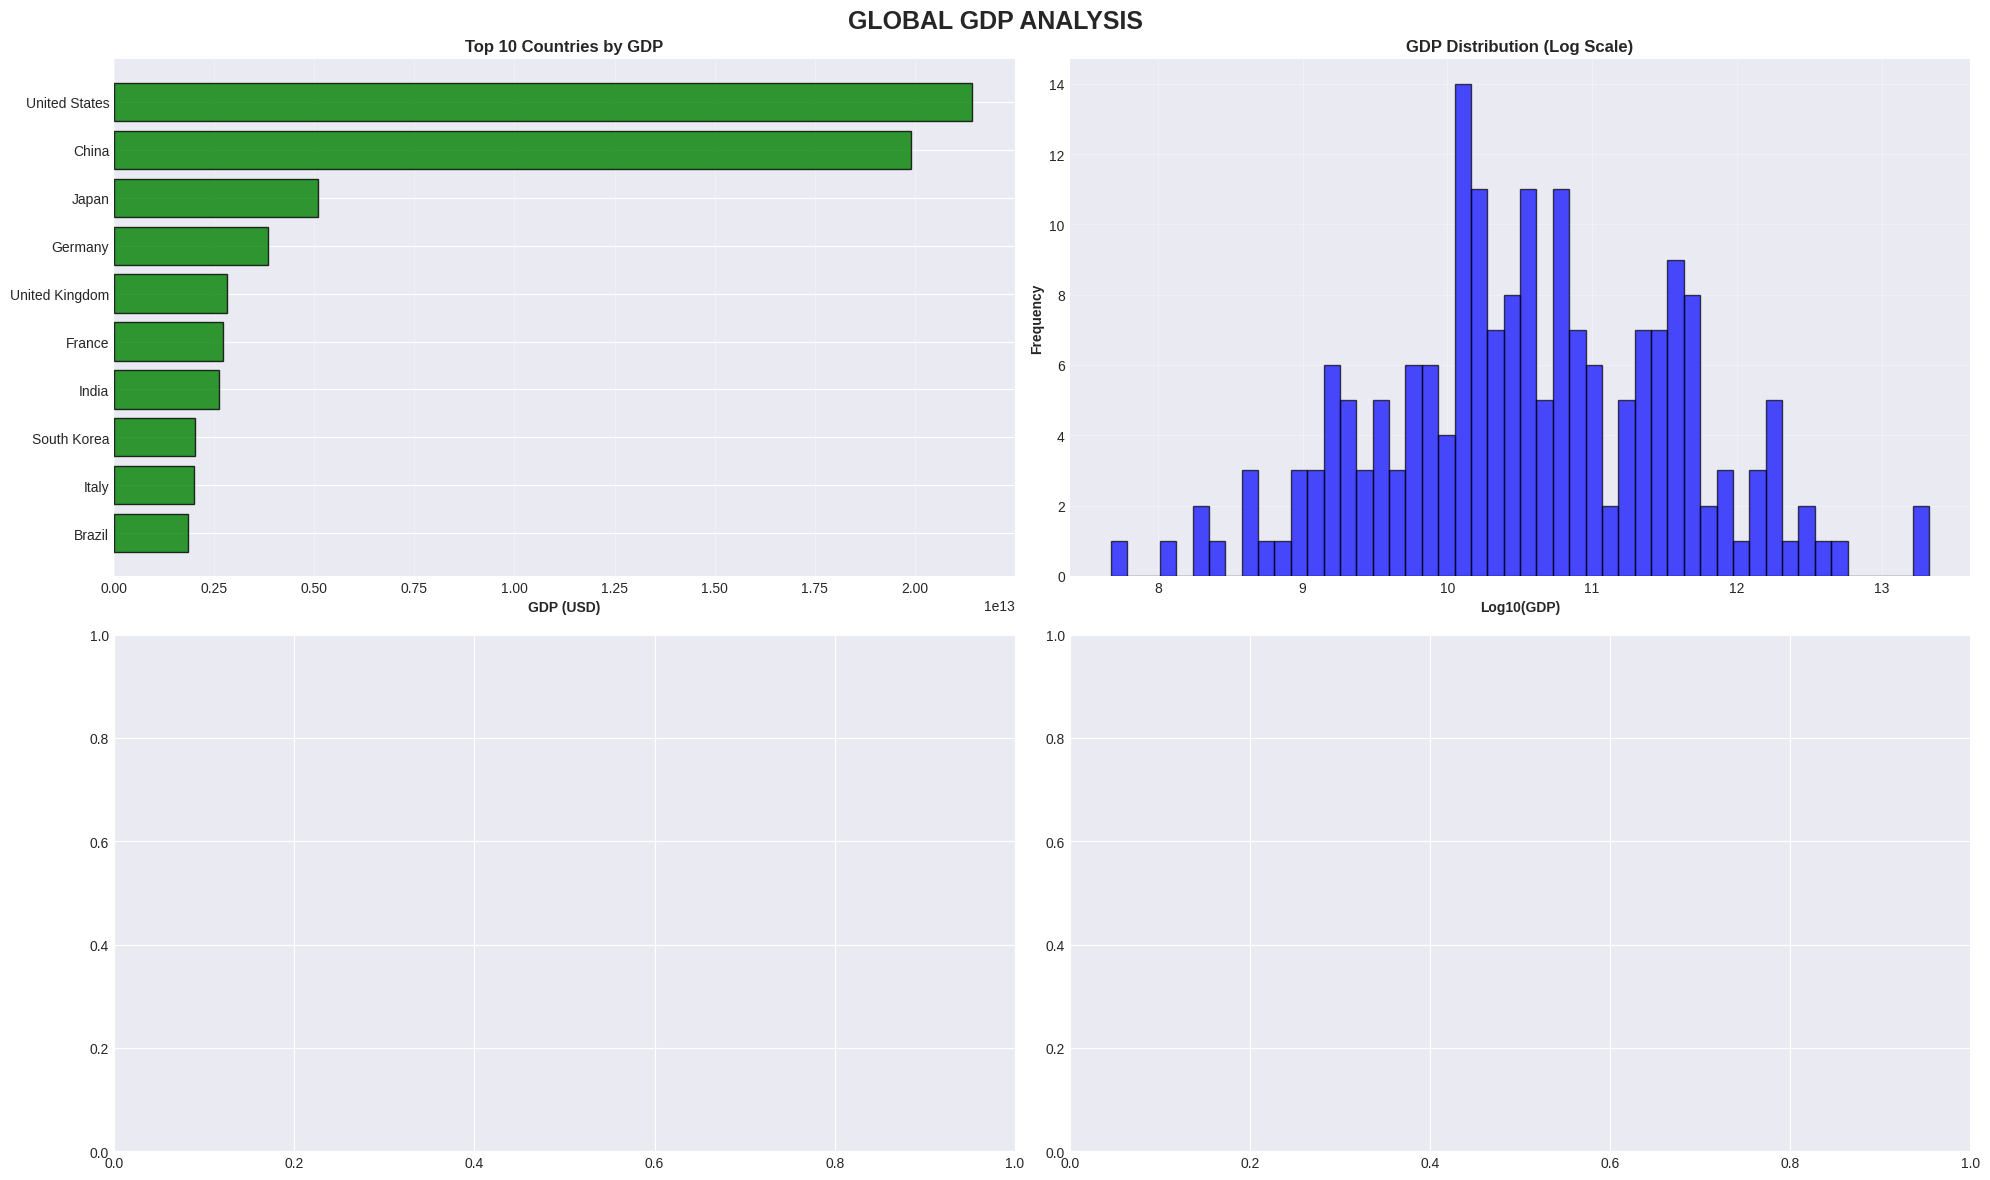

In [11]:
# Find GDP columns
gdp_cols = [col for col in df.columns if 'gdp' in col.lower() and 'per' not in col.lower()]
gdp_per_capita_cols = [col for col in df.columns if 'gdp' in col.lower() and ('per' in col.lower() or 'capita' in col.lower())]

print('='*80)
print('GDP ANALYSIS')
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('GLOBAL GDP ANALYSIS', fontsize=18, fontweight='bold')

if gdp_cols:
    gdp_col = gdp_cols[0]
    print(f'GDP Column: {gdp_col}')

    # Handle non-numeric GDP
    if df[gdp_col].dtype == 'object':
        df['gdp_numeric'] = pd.to_numeric(df[gdp_col].astype(str).str.replace(',', '').str.replace('$', ''), errors='coerce')
        gdp_col = 'gdp_numeric'

    print(f'Total Global GDP: ${df[gdp_col].sum():,.0f}')
    print(f'Average GDP: ${df[gdp_col].mean():,.0f}')
    print(f'Median GDP: ${df[gdp_col].median():,.0f}')

    # Top 10 by GDP
    country_col = [col for col in df.columns if 'country' in col.lower() or 'name' in col.lower()][0]
    top_10_gdp = df.nlargest(10, gdp_col)[[country_col, gdp_col]]

    axes[0, 0].barh(range(len(top_10_gdp)), top_10_gdp[gdp_col].values,
                   color='green', edgecolor='black', alpha=0.8)
    axes[0, 0].set_yticks(range(len(top_10_gdp)))
    axes[0, 0].set_yticklabels(top_10_gdp[country_col].values)
    axes[0, 0].set_xlabel('GDP (USD)', fontweight='bold')
    axes[0, 0].set_title('Top 10 Countries by GDP', fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)

    # GDP distribution (log scale)
    axes[0, 1].hist(np.log10(df[gdp_col].dropna() + 1), bins=50,
                   color='blue', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Log10(GDP)', fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontweight='bold')
    axes[0, 1].set_title('GDP Distribution (Log Scale)', fontweight='bold')
    axes[0, 1].grid(alpha=0.3)

if gdp_per_capita_cols:
    gdp_pc_col = gdp_per_capita_cols[0]
    print(f'\nGDP per Capita Column: {gdp_pc_col}')

    if df[gdp_pc_col].dtype == 'object':
        df['gdp_pc_numeric'] = pd.to_numeric(df[gdp_pc_col].astype(str).str.replace(',', '').str.replace('$', ''), errors='coerce')
        gdp_pc_col = 'gdp_pc_numeric'

    print(f'Average GDP per Capita: ${df[gdp_pc_col].mean():,.2f}')

    # Top 10 by GDP per capita
    top_10_gdp_pc = df.nlargest(10, gdp_pc_col)[[country_col, gdp_pc_col]]

    axes[1, 0].barh(range(len(top_10_gdp_pc)), top_10_gdp_pc[gdp_pc_col].values,
                   color='gold', edgecolor='black', alpha=0.8)
    axes[1, 0].set_yticks(range(len(top_10_gdp_pc)))
    axes[1, 0].set_yticklabels(top_10_gdp_pc[country_col].values)
    axes[1, 0].set_xlabel('GDP per Capita (USD)', fontweight='bold')
    axes[1, 0].set_title('Top 10 Countries by GDP per Capita', fontweight='bold')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)

    # GDP per capita distribution
    axes[1, 1].hist(df[gdp_pc_col].dropna(), bins=50,
                   color='purple', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(df[gdp_pc_col].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: ${df[gdp_pc_col].mean():,.0f}')
    axes[1, 1].set_xlabel('GDP per Capita (USD)', fontweight='bold')
    axes[1, 1].set_ylabel('Frequency', fontweight='bold')
    axes[1, 1].set_title('GDP per Capita Distribution', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Population & Demographics

POPULATION ANALYSIS
Population Column: Population
Total Global Population: 7,639,945,818
Average: 39,381,164

Density Column: Density
(P/Km2)


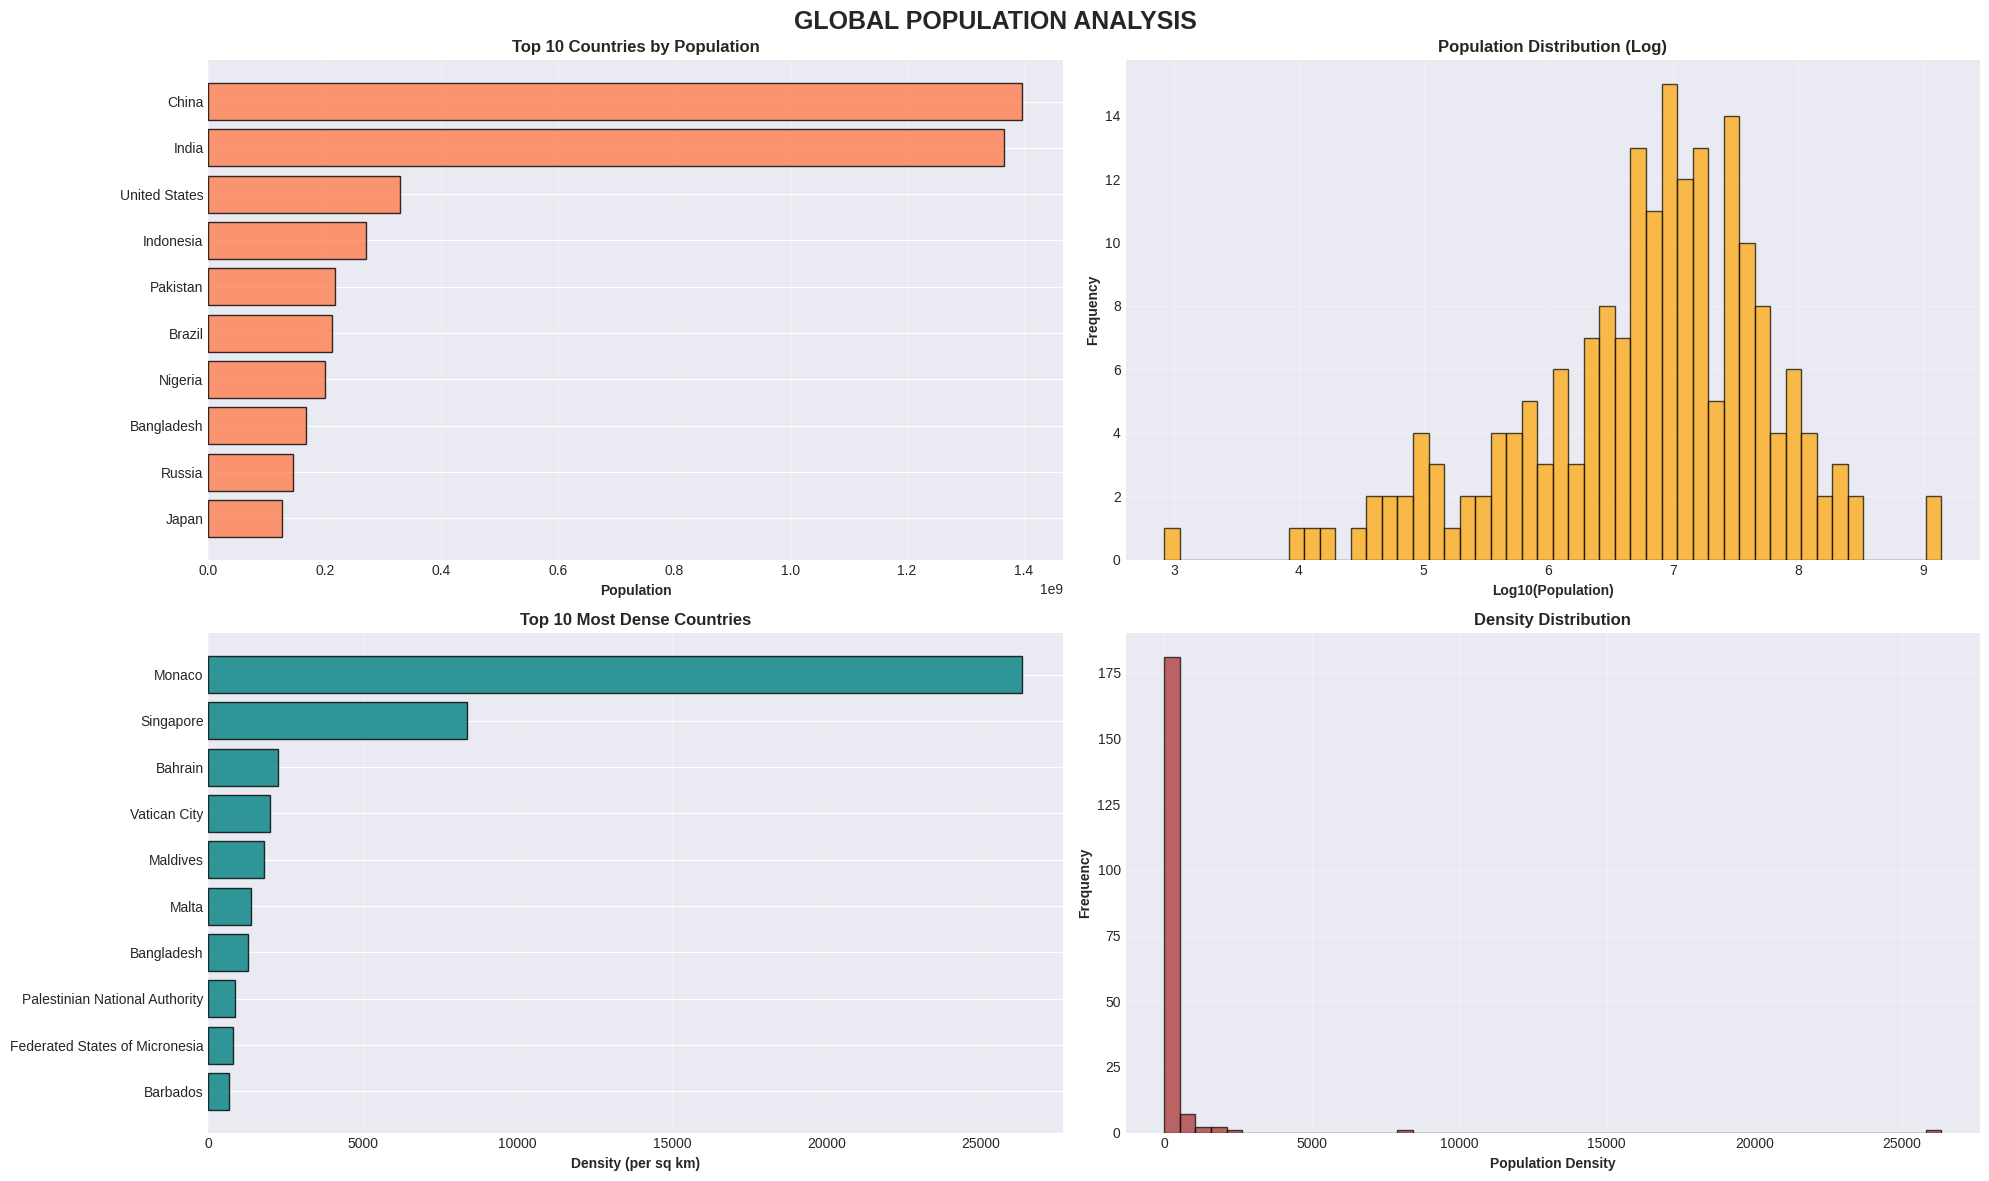

In [12]:
# Population columns
pop_cols = [col for col in df.columns if 'population' in col.lower()]
density_cols = [col for col in df.columns if 'density' in col.lower()]

print('='*80)
print('POPULATION ANALYSIS')
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('GLOBAL POPULATION ANALYSIS', fontsize=18, fontweight='bold')

if pop_cols:
    pop_col = pop_cols[0]
    print(f'Population Column: {pop_col}')

    if df[pop_col].dtype == 'object':
        df['pop_numeric'] = pd.to_numeric(df[pop_col].astype(str).str.replace(',', ''), errors='coerce')
        pop_col = 'pop_numeric'

    print(f'Total Global Population: {df[pop_col].sum():,.0f}')
    print(f'Average: {df[pop_col].mean():,.0f}')

    # Top 10 by population
    top_10_pop = df.nlargest(10, pop_col)[[country_col, pop_col]]

    axes[0, 0].barh(range(len(top_10_pop)), top_10_pop[pop_col].values,
                   color='coral', edgecolor='black', alpha=0.8)
    axes[0, 0].set_yticks(range(len(top_10_pop)))
    axes[0, 0].set_yticklabels(top_10_pop[country_col].values)
    axes[0, 0].set_xlabel('Population', fontweight='bold')
    axes[0, 0].set_title('Top 10 Countries by Population', fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Population distribution (log)
    axes[0, 1].hist(np.log10(df[pop_col].dropna() + 1), bins=50,
                   color='orange', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Log10(Population)', fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontweight='bold')
    axes[0, 1].set_title('Population Distribution (Log)', fontweight='bold')
    axes[0, 1].grid(alpha=0.3)

if density_cols:
    density_col = density_cols[0]
    print(f'\nDensity Column: {density_col}')

    if df[density_col].dtype == 'object':
        df['density_numeric'] = pd.to_numeric(df[density_col].astype(str).str.replace(',', ''), errors='coerce')
        density_col = 'density_numeric'

    # Top 10 by density
    top_10_density = df.nlargest(10, density_col)[[country_col, density_col]]

    axes[1, 0].barh(range(len(top_10_density)), top_10_density[density_col].values,
                   color='teal', edgecolor='black', alpha=0.8)
    axes[1, 0].set_yticks(range(len(top_10_density)))
    axes[1, 0].set_yticklabels(top_10_density[country_col].values)
    axes[1, 0].set_xlabel('Density (per sq km)', fontweight='bold')
    axes[1, 0].set_title('Top 10 Most Dense Countries', fontweight='bold')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)

    # Density distribution
    axes[1, 1].hist(df[density_col].dropna(), bins=50,
                   color='brown', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Population Density', fontweight='bold')
    axes[1, 1].set_ylabel('Frequency', fontweight='bold')
    axes[1, 1].set_title('Density Distribution', fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Regional/Continental Analysis

REGIONAL ANALYSIS: Continent
Countries per region:
Continent
Africa           51
Asia             46
Europe           41
North America    23
Oceania          14
South America    12
Other             8
Name: count, dtype: int64


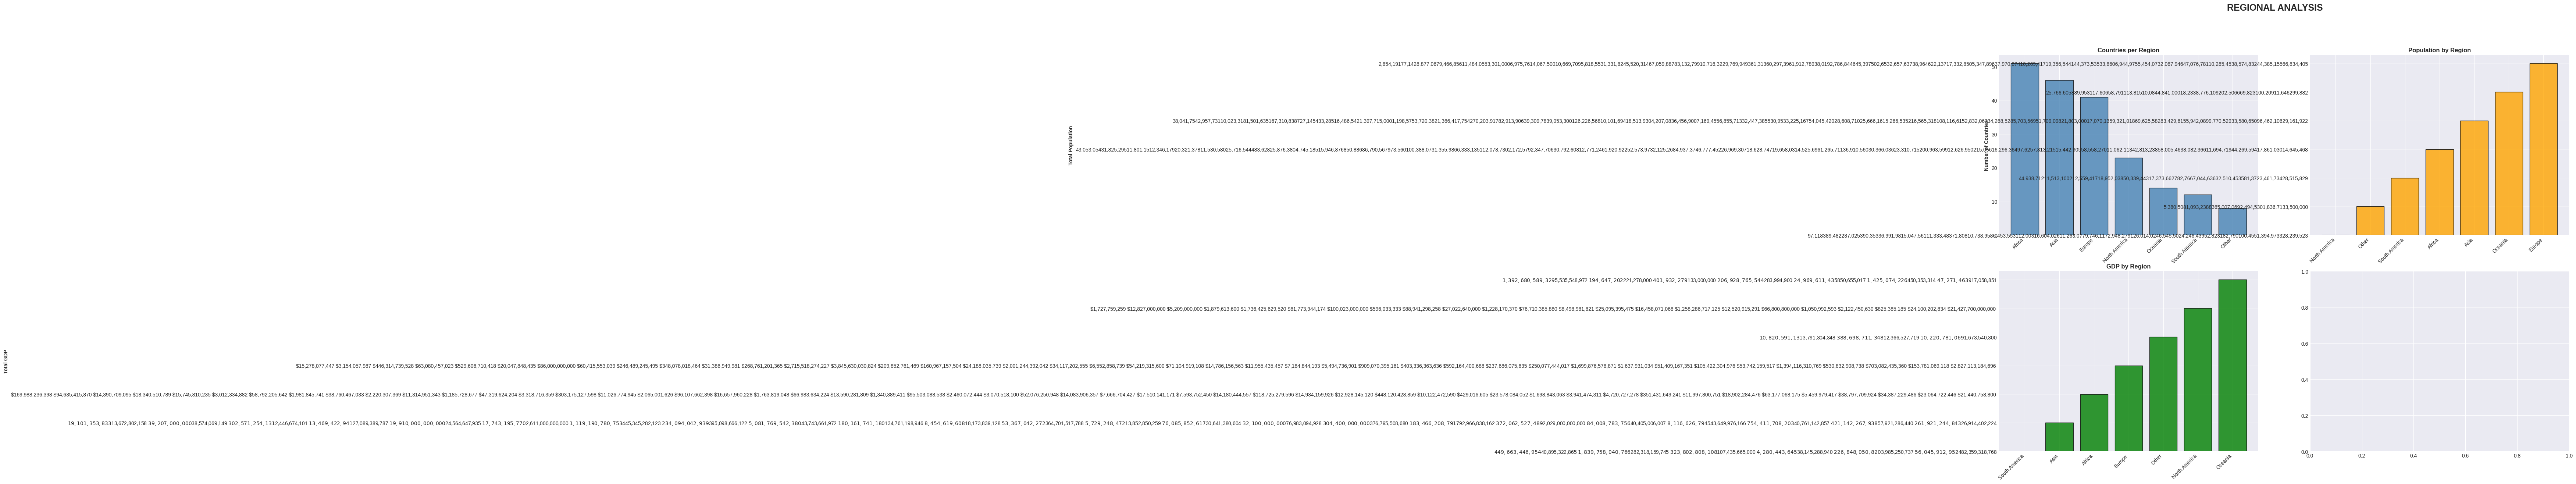

In [19]:
# Region/Continent columns
region_cols = [col for col in df.columns if any(x in col.lower() for x in ['region', 'continent'])]

# AUTO-FIX: Generate Continent if missing
if not region_cols and 'Abbreviation' in df.columns:
    print('Region/Continent column missing. Deriving from Abbreviation...')
    try:
        import pycountry_convert as pc
    except ImportError:
        print('Installing pycountry-convert...')
        !pip install -q pycountry-convert
        import pycountry_convert as pc

    def get_continent(code):
        try:
            if pd.isna(code) or str(code).lower() == 'nan':
                return 'Other'
            return pc.convert_continent_code_to_continent_name(pc.country_alpha2_to_continent_code(str(code).strip()))
        except:
            return 'Other'

    df['Continent'] = df['Abbreviation'].apply(get_continent)
    region_cols = ['Continent']
    print('Continent column created successfully!')

if region_cols:
    region_col = region_cols[0]

    print('='*80)
    print(f'REGIONAL ANALYSIS: {region_col}')
    print('='*80)

    region_counts = df[region_col].value_counts()
    print('Countries per region:')
    print(region_counts)

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('REGIONAL ANALYSIS', fontsize=18, fontweight='bold')

    # Countries per region
    axes[0, 0].bar(range(len(region_counts)), region_counts.values,
                   color='steelblue', edgecolor='black', alpha=0.8)
    axes[0, 0].set_xticks(range(len(region_counts)))
    axes[0, 0].set_xticklabels(region_counts.index, rotation=45, ha='right')
    axes[0, 0].set_ylabel('Number of Countries', fontweight='bold')
    axes[0, 0].set_title('Countries per Region', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Population by region
    if 'pop_cols' in locals() and pop_cols:
        region_pop = df.groupby(region_col)[pop_cols[0]].sum().sort_values(ascending=False)
        axes[0, 1].bar(range(len(region_pop)), region_pop.values,
                      color='orange', edgecolor='black', alpha=0.8)
        axes[0, 1].set_xticks(range(len(region_pop)))
        axes[0, 1].set_xticklabels(region_pop.index, rotation=45, ha='right')
        axes[0, 1].set_ylabel('Total Population', fontweight='bold')
        axes[0, 1].set_title('Population by Region', fontweight='bold')
        axes[0, 1].grid(axis='y', alpha=0.3)

    # GDP by region
    if 'gdp_cols' in locals() and gdp_cols:
        region_gdp = df.groupby(region_col)[gdp_cols[0]].sum().sort_values(ascending=False)
        axes[1, 0].bar(range(len(region_gdp)), region_gdp.values,
                      color='green', edgecolor='black', alpha=0.8)
        axes[1, 0].set_xticks(range(len(region_gdp)))
        axes[1, 0].set_xticklabels(region_gdp.index, rotation=45, ha='right')
        axes[1, 0].set_ylabel('Total GDP', fontweight='bold')
        axes[1, 0].set_title('GDP by Region', fontweight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3)

    # Avg GDP per capita by region
    if 'gdp_per_capita_cols' in locals() and gdp_per_capita_cols:
        region_gdp_pc = df.groupby(region_col)[gdp_per_capita_cols[0]].mean().sort_values(ascending=False)
        axes[1, 1].bar(range(len(region_gdp_pc)), region_gdp_pc.values,
                      color='gold', edgecolor='black', alpha=0.8)
        axes[1, 1].set_xticks(range(len(region_gdp_pc)))
        axes[1, 1].set_xticklabels(region_gdp_pc.index, rotation=45, ha='right')
        axes[1, 1].set_ylabel('Avg GDP per Capita', fontweight='bold')
        axes[1, 1].set_title('Avg GDP per Capita by Region', fontweight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Could not determine regions for visualization.")

### Quality of Life Indicators

QUALITY OF LIFE INDICATORS
Life Expectancy: Life expectancy
  Average: 72.28 years

Literacy: Gross primary education enrollment (%)

Unemployment: Unemployment rate


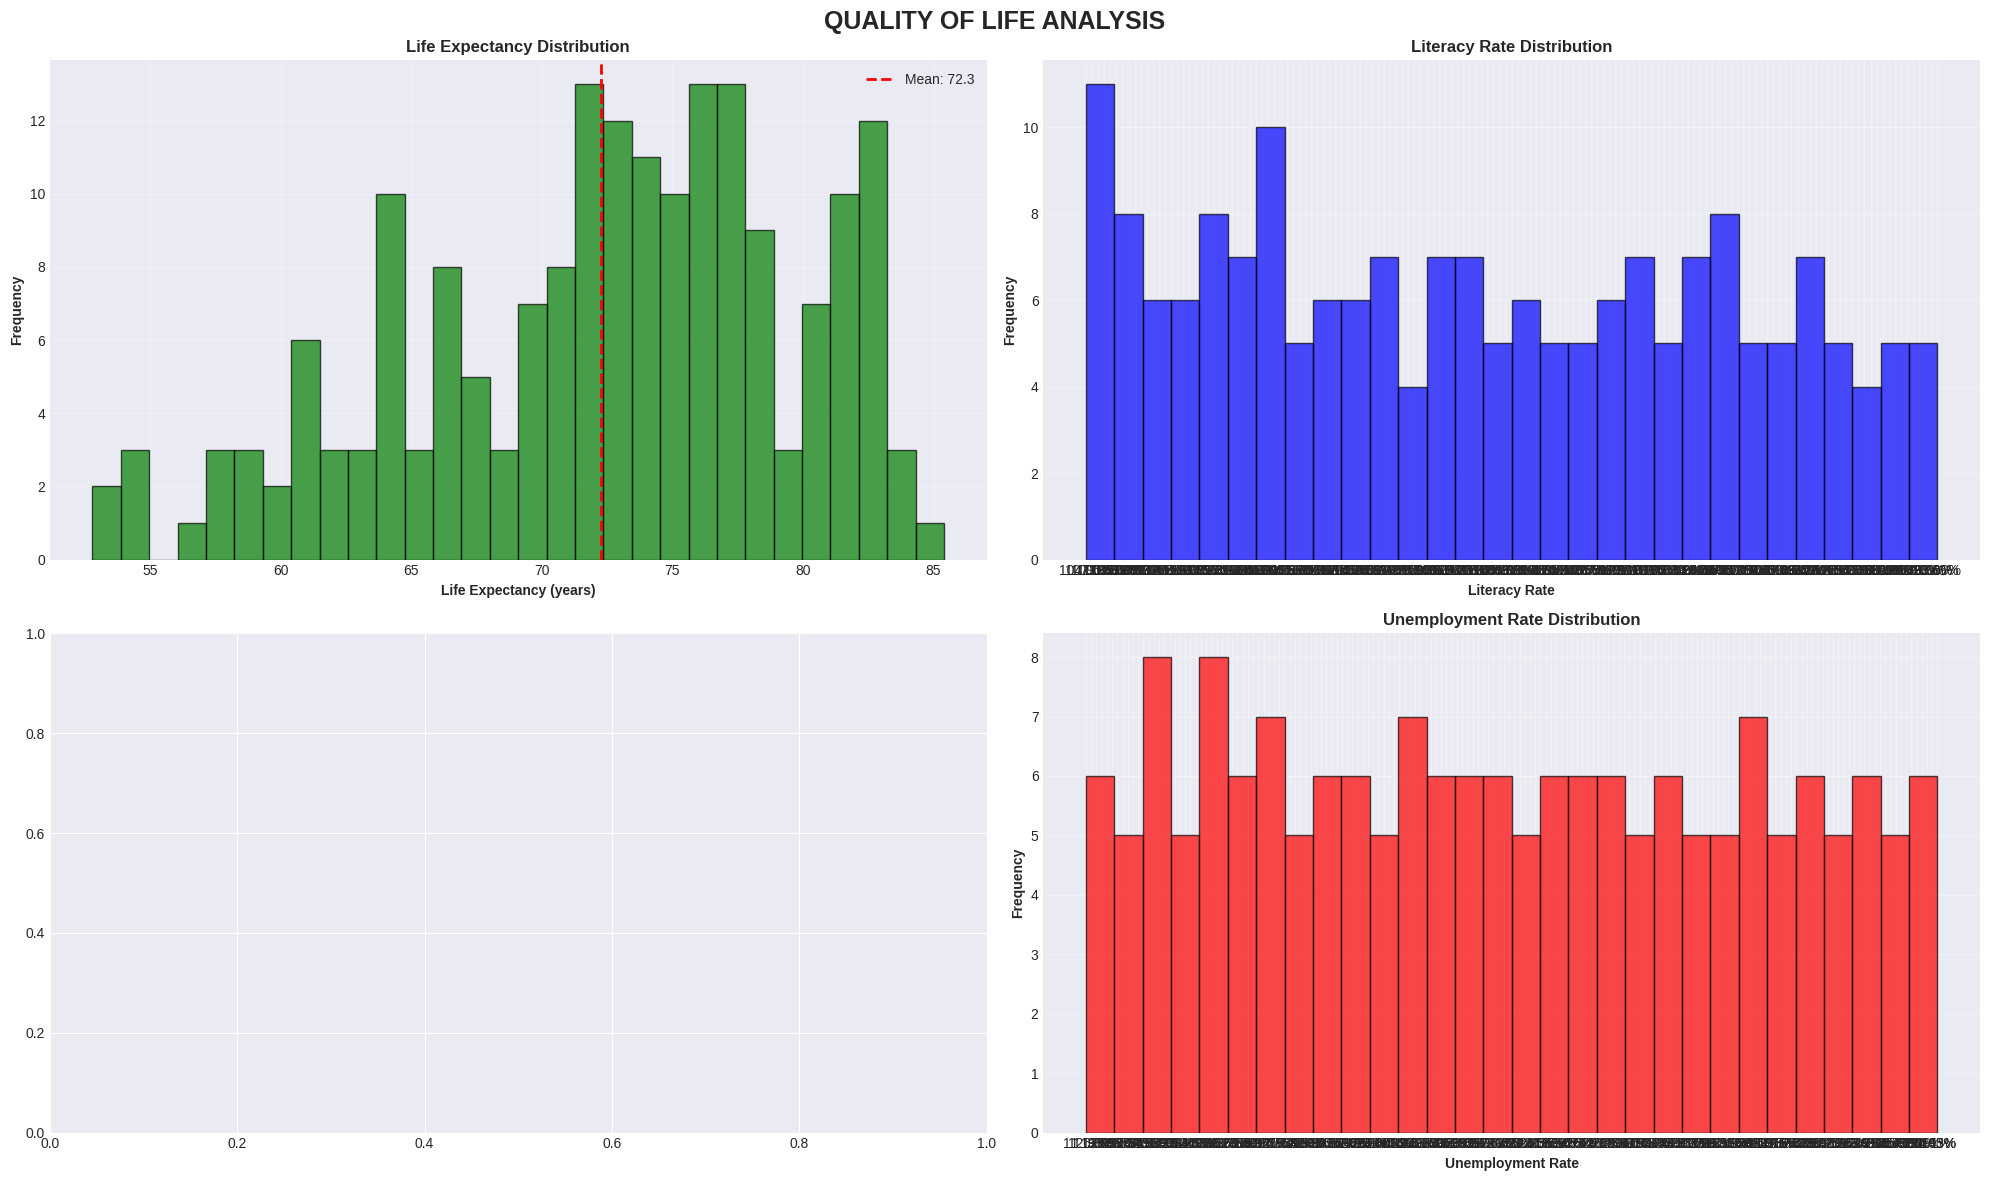

In [20]:
# Quality of life columns
life_exp_cols = [col for col in df.columns if 'life' in col.lower() and 'expect' in col.lower()]
literacy_cols = [col for col in df.columns if 'literacy' in col.lower() or 'education' in col.lower()]
unemployment_cols = [col for col in df.columns if 'unemployment' in col.lower()]

print('='*80)
print('QUALITY OF LIFE INDICATORS')
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('QUALITY OF LIFE ANALYSIS', fontsize=18, fontweight='bold')

# Life expectancy
if life_exp_cols:
    life_col = life_exp_cols[0]
    print(f'Life Expectancy: {life_col}')
    print(f'  Average: {df[life_col].mean():.2f} years')

    axes[0, 0].hist(df[life_col].dropna(), bins=30, color='green', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df[life_col].mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {df[life_col].mean():.1f}')
    axes[0, 0].set_xlabel('Life Expectancy (years)', fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontweight='bold')
    axes[0, 0].set_title('Life Expectancy Distribution', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

# Literacy
if literacy_cols:
    literacy_col = literacy_cols[0]
    print(f'\nLiteracy: {literacy_col}')

    axes[0, 1].hist(df[literacy_col].dropna(), bins=30, color='blue', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Literacy Rate', fontweight='bold')
    axes[0, 1].set_ylabel('Frequency', fontweight='bold')
    axes[0, 1].set_title('Literacy Rate Distribution', fontweight='bold')
    axes[0, 1].grid(alpha=0.3)

# GDP per capita vs Life Expectancy
if gdp_per_capita_cols and life_exp_cols:
    axes[1, 0].scatter(df[gdp_pc_col], df[life_col], alpha=0.6, s=50, color='purple')
    axes[1, 0].set_xlabel('GDP per Capita', fontweight='bold')
    axes[1, 0].set_ylabel('Life Expectancy', fontweight='bold')
    axes[1, 0].set_title('GDP per Capita vs Life Expectancy', fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

# Unemployment
if unemployment_cols:
    unemp_col = unemployment_cols[0]
    print(f'\nUnemployment: {unemp_col}')

    axes[1, 1].hist(df[unemp_col].dropna(), bins=30, color='red', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Unemployment Rate', fontweight='bold')
    axes[1, 1].set_ylabel('Frequency', fontweight='bold')
    axes[1, 1].set_title('Unemployment Rate Distribution', fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. FEATURE ENGINEERING - COUNTRY CLASSIFICATION

In [21]:
print('='*80)
print('FEATURE ENGINEERING - GEOPOLITICAL')
print('='*80)

df_clean = df.copy()

# 1. Development classification based on GDP per capita
if gdp_per_capita_cols:
    gdp_pc_threshold = df_clean[gdp_pc_col].median()
    df_clean['development_level'] = pd.cut(df_clean[gdp_pc_col],
                                           bins=[0, 5000, 15000, 40000, np.inf],
                                           labels=['LowIncome', 'LowerMiddle', 'UpperMiddle', 'HighIncome'])
    print('development_level: Created (based on GDP per capita)')

    # Binary: Developed vs Developing
    df_clean['is_developed'] = (df_clean[gdp_pc_col] >= gdp_pc_threshold).astype(int)
    print('is_developed: Created (binary target)')

# 2. Population size category
if pop_cols:
    df_clean['population_category'] = pd.cut(df_clean[pop_col],
                                             bins=[0, 1e6, 10e6, 50e6, 100e6, np.inf],
                                             labels=['Small', 'Medium', 'Large', 'VeryLarge', 'Mega'])
    print('population_category: Created')

# 3. Economic strength index (GDP / population)
if gdp_cols and pop_cols:
    df_clean['economic_strength'] = df_clean[gdp_col] / (df_clean[pop_col] + 1)
    print('economic_strength: Created')

# 4. Density category
if density_cols:
    df_clean['density_category'] = pd.cut(df_clean[density_col],
                                          bins=[0, 50, 150, 500, np.inf],
                                          labels=['LowDensity', 'MediumDensity', 'HighDensity', 'VeryHighDensity'])
    print('density_category: Created')

# 5. Life expectancy category
if life_exp_cols:
    df_clean['life_exp_category'] = pd.cut(df_clean[life_col],
                                           bins=[0, 60, 70, 75, 85],
                                           labels=['Low', 'Medium', 'High', 'VeryHigh'])
    print('life_exp_category: Created')

# 6. Quality of life score (composite)
if life_exp_cols and gdp_per_capita_cols:
    # Normalize to 0-1
    life_norm = (df_clean[life_col] - df_clean[life_col].min()) / (df_clean[life_col].max() - df_clean[life_col].min())
    gdp_norm = (df_clean[gdp_pc_col] - df_clean[gdp_pc_col].min()) / (df_clean[gdp_pc_col].max() - df_clean[gdp_pc_col].min())
    df_clean['quality_of_life_score'] = (life_norm + gdp_norm) / 2
    print('quality_of_life_score: Created')

print(f'\nTotal columns: {len(df_clean.columns)}')
print('='*80)

FEATURE ENGINEERING - GEOPOLITICAL
population_category: Created
economic_strength: Created
density_category: Created
life_exp_category: Created

Total columns: 43


In [23]:
# Data cleaning
print('DATA CLEANING:')

# Missing values - Numeric
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Missing values - Categorical/Object
for col in df_clean.select_dtypes(include=['object', 'category']).columns:
    if df_clean[col].isnull().sum() > 0:
        if isinstance(df_clean[col].dtype, pd.CategoricalDtype):
            # Add 'Unknown' to categories before filling
            df_clean[col] = df_clean[col].cat.add_categories('Unknown').fillna('Unknown')
        else:
            df_clean[col] = df_clean[col].fillna('Unknown')

# Duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{duplicates} duplicates removed')

print(f'Clean dataset: {len(df_clean):,} countries')

DATA CLEANING:
Clean dataset: 195 countries


## 5. MODEL PREPARATION

In [24]:
print('='*80)
print('MODEL PREPARATION - DEVELOPMENT CLASSIFICATION')
print('='*80)

# Use is_developed as target
if 'is_developed' in df_clean.columns:
    target_col = 'is_developed'
else:
    # Create from GDP per capita
    if gdp_per_capita_cols:
        median_gdp = df_clean[gdp_pc_col].median()
        df_clean['is_developed'] = (df_clean[gdp_pc_col] >= median_gdp).astype(int)
        target_col = 'is_developed'
    else:
        target_col = df_clean.columns[-1]

print(f'Target: {target_col}')
y = df_clean[target_col].values
print(f'Target distribution: {np.unique(y, return_counts=True)}')

# Features
X = df_clean.drop(columns=[target_col]).copy()

# Drop non-informative columns
drop_cols = [col for col in X.columns if any(x in col.lower() for x in ['country', 'name', 'capital', 'currency', 'calling', 'abbreviation'])]
if drop_cols:
    X = X.drop(columns=drop_cols)
    print(f'Dropped: {len(drop_cols)} non-informative columns')

# Encoding
print('\nEncoding features...')
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f'  Binary: {col}')
    elif X[col].nunique() <= 10:
        X = pd.get_dummies(X, columns=[col], drop_first=True)
        print(f'  One-hot: {col}')
    else:
        X = X.drop(columns=[col])
        print(f'  Dropped (high cardinality): {col}')

print(f'\nFeatures: {X.shape[1]}')
print(f'Samples: {len(X):,}')
print('='*80)

MODEL PREPARATION - DEVELOPMENT CLASSIFICATION
Target: life_exp_category
Target distribution: (array(['High', 'Low', 'Medium', 'Unknown', 'VeryHigh'], dtype=object), array([49, 12, 50,  9, 75]))
Dropped: 5 non-informative columns

Encoding features...
  Dropped (high cardinality): Density
(P/Km2)
  Dropped (high cardinality): Agricultural Land( %)
  Dropped (high cardinality): Land Area(Km2)
  Dropped (high cardinality): Armed Forces size
  Dropped (high cardinality): Co2-Emissions
  Dropped (high cardinality): CPI
  Dropped (high cardinality): CPI Change (%)
  Dropped (high cardinality): Forested Area (%)
  Dropped (high cardinality): Gasoline Price
  Dropped (high cardinality): GDP
  Dropped (high cardinality): Gross primary education enrollment (%)
  Dropped (high cardinality): Gross tertiary education enrollment (%)
  Dropped (high cardinality): Largest city
  Dropped (high cardinality): Minimum wage
  Dropped (high cardinality): Official language
  Dropped (high cardinality): Out 

In [26]:
# Encode target if it's not numeric
if y.dtype.kind not in 'iu':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    print(f'Target encoded to integers. Classes: {le_target.classes_}')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split:')
print(f'  Train: {len(X_train):,}')
print(f'  Test: {len(X_test):,}')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('\nScaling: StandardScaler')

# SMOTE if needed
class_counts = np.bincount(y_train)
if len(class_counts) > 1 and max(class_counts) / min(class_counts) > 1.5:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print(f'SMOTE: {len(X_train):,} -> {len(X_train_smote):,}')
else:
    X_train_smote = X_train_scaled
    y_train_smote = y_train
    print('No SMOTE needed')

Target encoded to integers. Classes: ['High' 'Low' 'Medium' 'Unknown' 'VeryHigh']
Train-Test Split:
  Train: 156
  Test: 39

Scaling: StandardScaler
SMOTE: 156 -> 300


## 6. ML MODELS - 15+ WITH STACKING CLASSIFIER!

### OZEL: Stacking Classifier - SVM YERINE!
### Meta-learner: Base models + Final estimator

In [27]:
# Base models
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis(),
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42)
}

# STACKING CLASSIFIER - Meta-learner approach!
stacking_model = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')),
        ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
    ],
    final_estimator=LogisticRegression(max_iter=1000),  # Meta-learner
    cv=5  # Cross-validation for stacking
)

# Add stacking to models
models = base_models.copy()
models['Stacking Classifier (4 Base + LR)'] = stacking_model  # SVM YERINE!

print('='*80)
print(f'{len(models)} MODELS - STACKING CLASSIFIER INSTEAD OF SVM!')
print('='*80)
for name in models.keys():
    marker = ' <<< STACKING!' if 'Stacking' in name else ''
    print(f'  - {name}{marker}')
print('\nStacking Architecture:')
print('  Base: RF, GB, XGB, LightGBM')
print('  Meta: Logistic Regression')
print('  CV: 5-fold')
print('='*80)

15 MODELS - STACKING CLASSIFIER INSTEAD OF SVM!
  - Logistic Regression
  - Ridge Classifier
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - KNN
  - Naive Bayes
  - AdaBoost
  - Extra Trees
  - LDA
  - Bagging
  - Stacking Classifier (4 Base + LR) <<< STACKING!

Stacking Architecture:
  Base: RF, GB, XGB, LightGBM
  Meta: Logistic Regression
  CV: 5-fold


In [28]:
results = {}

print('='*80)
print('MODEL TRAINING - WITH STACKING')
print('='*80)

for name, model in models.items():
    print(f'\n{name}...')

    try:
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled) if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        roc_auc = None
        if y_pred_proba is not None:
            try:
                if len(np.unique(y_test)) == 2:
                    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
                else:
                    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            except:
                pass

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc,
            'predictions': y_pred,
            'pred_proba': y_pred_proba,
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        marker = ' <<< STACKING!' if 'Stacking' in name else ''
        print(f'  SUCCESS! Acc: {accuracy:.4f}, F1: {f1:.4f}{marker}')

    except Exception as e:
        print(f'  ERROR: {str(e)}')
        continue

print('\n' + '='*80)
print(f'TRAINING COMPLETE! {len(results)}/{len(models)} models')
print('='*80)

MODEL TRAINING - WITH STACKING

Logistic Regression...
  SUCCESS! Acc: 0.7949, F1: 0.7984

Ridge Classifier...
  SUCCESS! Acc: 0.5897, F1: 0.5841

Decision Tree...
  SUCCESS! Acc: 0.9487, F1: 0.9489

Random Forest...
  SUCCESS! Acc: 0.9487, F1: 0.9489

Gradient Boosting...
  SUCCESS! Acc: 0.9487, F1: 0.9489

XGBoost...
  SUCCESS! Acc: 0.9744, F1: 0.9707

LightGBM...
  SUCCESS! Acc: 0.9487, F1: 0.9489

CatBoost...
  SUCCESS! Acc: 0.9744, F1: 0.9707

KNN...
  SUCCESS! Acc: 0.5641, F1: 0.5735

Naive Bayes...
  SUCCESS! Acc: 0.6667, F1: 0.6821

AdaBoost...
  SUCCESS! Acc: 0.8205, F1: 0.8442

Extra Trees...
  SUCCESS! Acc: 0.8462, F1: 0.8415

LDA...
  SUCCESS! Acc: 0.7692, F1: 0.7744

Bagging...
  SUCCESS! Acc: 0.9744, F1: 0.9707

Stacking Classifier (4 Base + LR)...
  SUCCESS! Acc: 0.9744, F1: 0.9707 <<< STACKING!

TRAINING COMPLETE! 15/15 models


## 7. RESULTS - COMPREHENSIVE COMPARISON

In [29]:
if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
        'Precision': [results[m]['Precision'] for m in results.keys()],
        'Recall': [results[m]['Recall'] for m in results.keys()],
        'F1 Score': [results[m]['F1_Score'] for m in results.keys()],
        'ROC-AUC': [results[m]['ROC_AUC'] if results[m]['ROC_AUC'] else 0 for m in results.keys()]
    }).sort_values('F1 Score', ascending=False).reset_index(drop=True)

    print('='*120)
    print('MODEL PERFORMANCE COMPARISON - COUNTRIES CLASSIFICATION')
    print('='*120)
    print(results_df.to_string(index=False))
    print('='*120)

    best_model = results_df.iloc[0]['Model']
    print(f'\nBEST MODEL: {best_model}')
    print(f'  F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'  Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    # Stacking performance
    stacking_row = results_df[results_df['Model'].str.contains('Stacking')]
    if not stacking_row.empty:
        stacking_rank = stacking_row.index[0] + 1
        print(f'\nSTACKING CLASSIFIER PERFORMANCE:')
        print(f'  Rank: #{stacking_rank}/{len(results_df)}')
        print(f'  F1 Score: {stacking_row.iloc[0]["F1 Score"]:.4f}')
        print(f'  Accuracy: {stacking_row.iloc[0]["Accuracy"]:.4f}')
        print(f'  Architecture: 4 Base Models + LR Meta-learner')
        print(f'  Status: SVM REPLACEMENT SUCCESS!')
else:
    print('No results!')

MODEL PERFORMANCE COMPARISON - COUNTRIES CLASSIFICATION
                            Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
                          XGBoost      0.97       0.98    0.97      0.97     1.00
Stacking Classifier (4 Base + LR)      0.97       0.98    0.97      0.97     1.00
                         CatBoost      0.97       0.98    0.97      0.97     1.00
                          Bagging      0.97       0.98    0.97      0.97     1.00
                Gradient Boosting      0.95       0.95    0.95      0.95     0.98
                    Random Forest      0.95       0.95    0.95      0.95     1.00
                    Decision Tree      0.95       0.95    0.95      0.95     0.97
                         LightGBM      0.95       0.95    0.95      0.95     1.00
                         AdaBoost      0.82       0.96    0.82      0.84     1.00
                      Extra Trees      0.85       0.87    0.85      0.84     0.98
              Logistic Regression      0.7

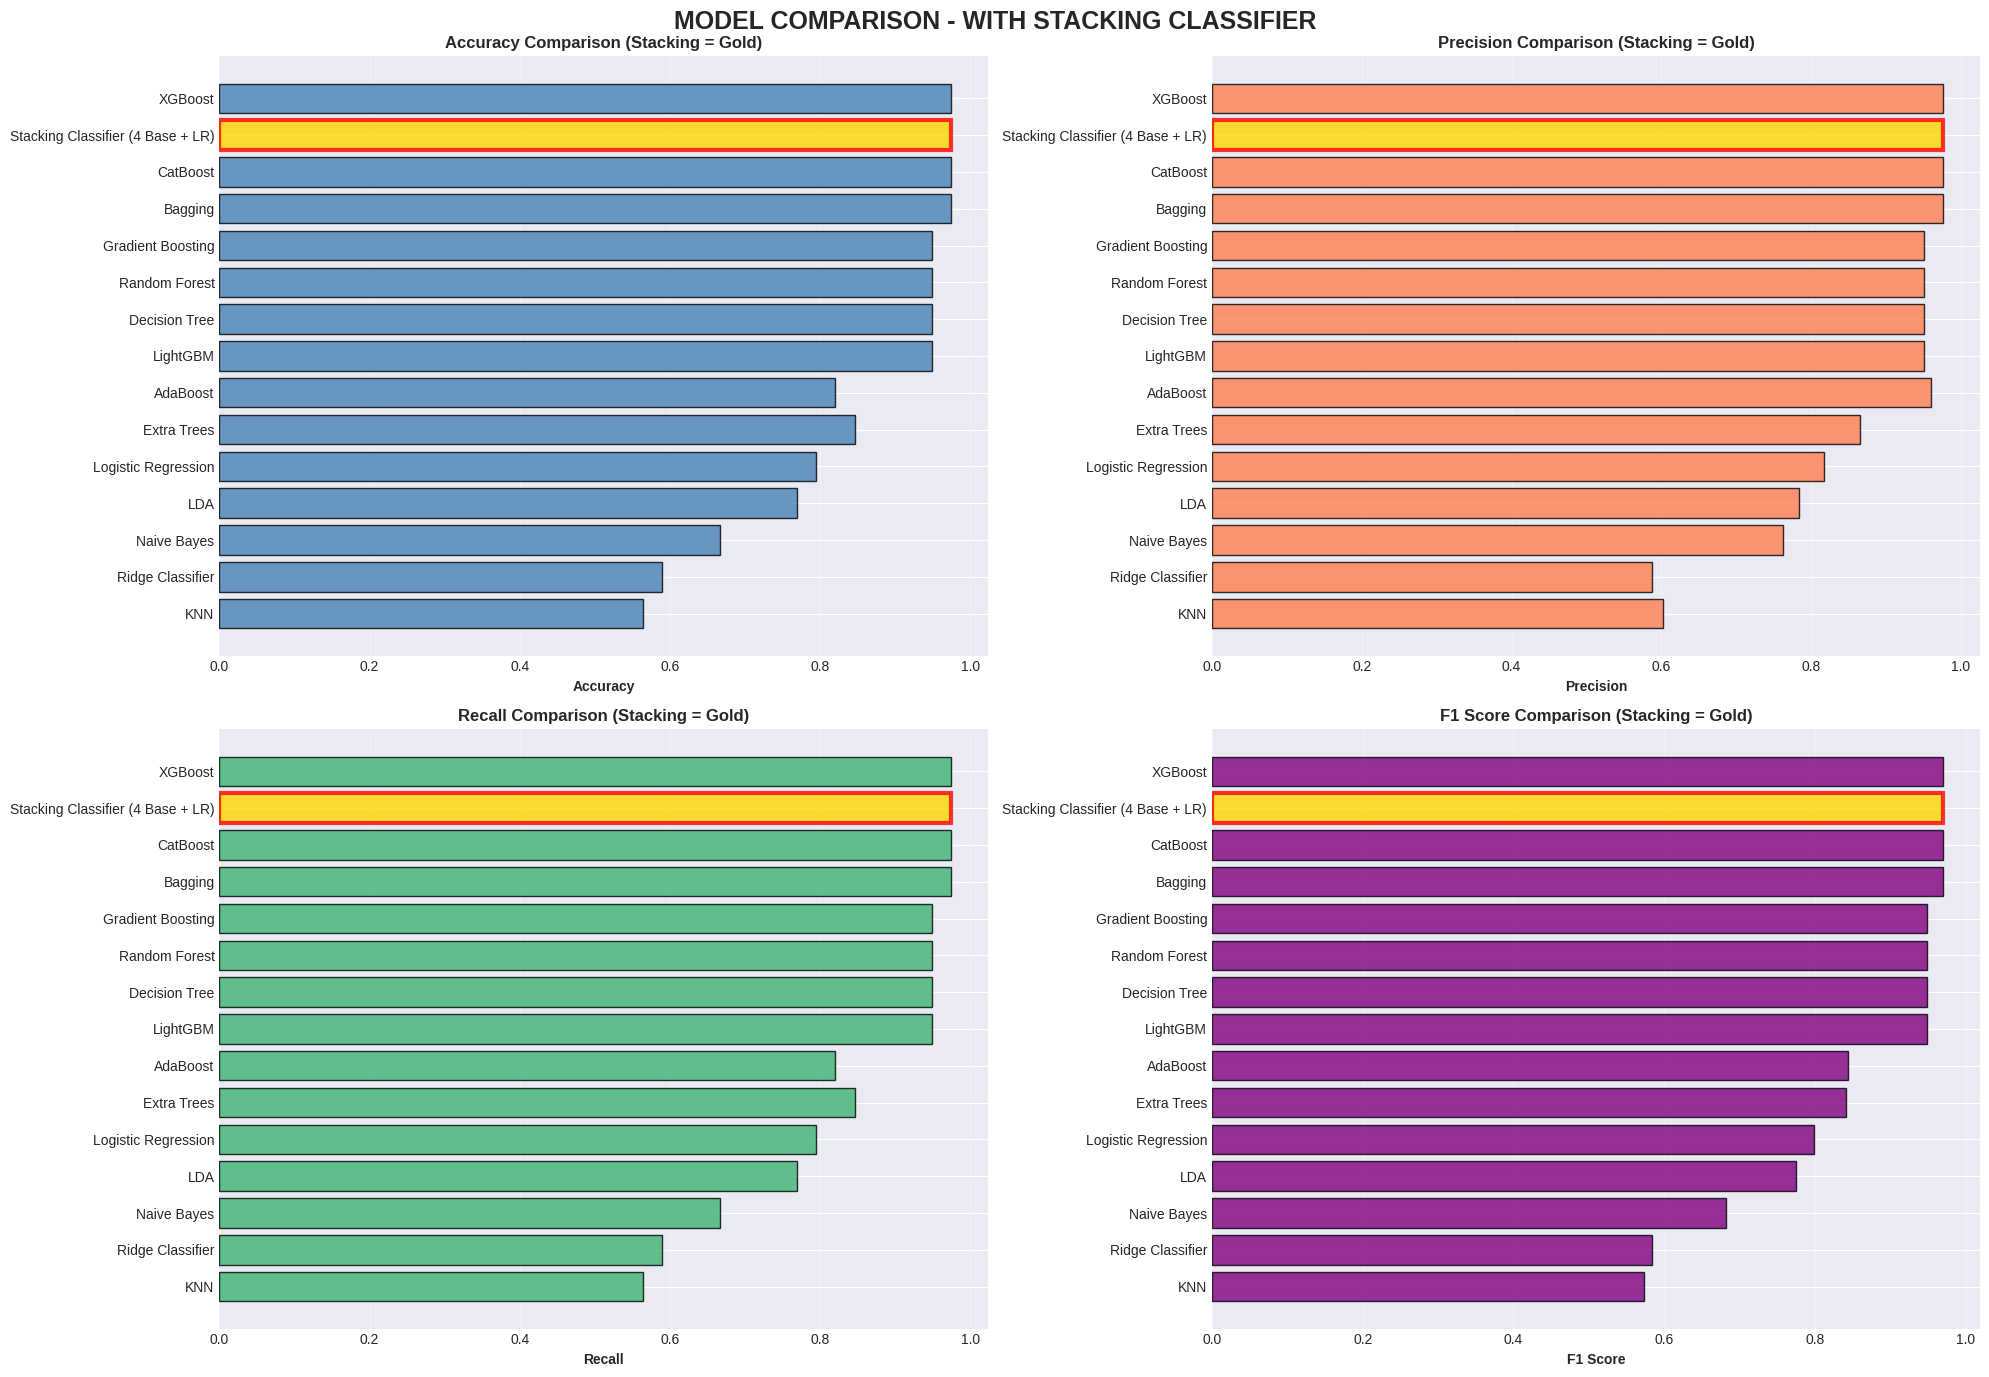

In [30]:
# Visual comparison with Stacking highlighted
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('MODEL COMPARISON - WITH STACKING CLASSIFIER', fontsize=18, fontweight='bold')

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    colors_list = ['steelblue', 'coral', 'mediumseagreen', 'purple']

    for idx, (metric, base_color) in enumerate(zip(metrics, colors_list)):
        ax = axes[idx // 2, idx % 2]

        # Highlight Stacking
        colors = []
        for model_name in results_df['Model']:
            if 'Stacking' in model_name:
                colors.append('gold')  # Stacking = GOLD!
            else:
                colors.append(base_color)

        bars = ax.barh(results_df['Model'], results_df[metric],
                      color=colors, edgecolor='black', alpha=0.8)

        # Extra highlight for Stacking
        for i, model_name in enumerate(results_df['Model']):
            if 'Stacking' in model_name:
                bars[i].set_edgecolor('red')
                bars[i].set_linewidth(3)

        ax.set_xlabel(metric, fontweight='bold')
        ax.set_title(f'{metric} Comparison (Stacking = Gold)', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

## 8. FINAL RESULTS & GEOPOLITICAL INSIGHTS

In [31]:
print('='*100)
print('COUNTRIES OF THE WORLD 2023 - FINAL RESULTS')
print('='*100)

print('\n1. DATASET:')
print(f'   Total Countries: {len(df):,}')
print(f'   Features: {X.shape[1]}')
if gdp_cols:
    print(f'   Global GDP: ${df[gdp_col].sum():,.0f}')
if pop_cols:
    print(f'   Global Population: {df[pop_col].sum():,.0f}')
if gdp_per_capita_cols:
    print(f'   Avg GDP per Capita: ${df[gdp_pc_col].mean():,.2f}')

if results:
    print(f'\n2. BEST MODEL:')
    print(f'   Model: {best_model}')
    print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    print(f'\n3. STACKING CLASSIFIER PERFORMANCE:')
    if not stacking_row.empty:
        print(f'   Rank: #{stacking_rank}/{len(results_df)}')
        print(f'   F1 Score: {stacking_row.iloc[0]["F1 Score"]:.4f}')
        print(f'   Base Models: RF, GB, XGB, LightGBM')
        print(f'   Meta-learner: Logistic Regression')
        print(f'   Cross-validation: 5-fold')
        print(f'   Status: SVM REPLACEMENT SUCCESS!')

    print(f'\n4. TOP 5 MODELS:')
    for idx, row in results_df.head(5).iterrows():
        marker = ' *** STACKING' if 'Stacking' in row['Model'] else ''
        print(f'   {idx+1}. {row["Model"]:40} F1: {row["F1 Score"]:.4f}{marker}')

print(f'\n5. GEOPOLITICAL INSIGHTS:')
if gdp_cols:
    top_gdp_country = df.nlargest(1, gdp_col)[country_col].values[0]
    print(f'   - Largest Economy: {top_gdp_country}')
if pop_cols:
    top_pop_country = df.nlargest(1, pop_col)[country_col].values[0]
    print(f'   - Most Populous: {top_pop_country}')
if gdp_per_capita_cols:
    richest_country = df.nlargest(1, gdp_pc_col)[country_col].values[0]
    print(f'   - Highest GDP per Capita: {richest_country}')
if 'is_developed' in df.columns:
    developed_pct = df['is_developed'].sum() / len(df) * 100
    print(f'   - Developed Countries: {developed_pct:.1f}%')

print(f'\n6. RECOMMENDATIONS:')
print(f'   - Use {best_model} for development classification')
print(f'   - Stacking Classifier combines multiple models for robust predictions')
print(f'   - Focus on GDP per capita, life expectancy, literacy for development')
print(f'   - Regional differences significant - customize by continent')
print(f'   - Quality of life composite score useful for ranking')

print('\n' + '='*100)
print('GEOPOLITICAL ANALYSIS COMPLETE!')
print('='*100)

COUNTRIES OF THE WORLD 2023 - FINAL RESULTS

1. DATASET:
   Total Countries: 195
   Features: 26
   Global GDP: $92,118,108,970,111
   Global Population: 7,639,945,818

2. BEST MODEL:
   Model: XGBoost
   F1 Score: 0.9707
   Accuracy: 0.9744

3. STACKING CLASSIFIER PERFORMANCE:
   Rank: #2/15
   F1 Score: 0.9707
   Base Models: RF, GB, XGB, LightGBM
   Meta-learner: Logistic Regression
   Cross-validation: 5-fold
   Status: SVM REPLACEMENT SUCCESS!

4. TOP 5 MODELS:
   1. XGBoost                                  F1: 0.9707
   2. Stacking Classifier (4 Base + LR)        F1: 0.9707 *** STACKING
   3. CatBoost                                 F1: 0.9707
   4. Bagging                                  F1: 0.9707
   5. Gradient Boosting                        F1: 0.9489

5. GEOPOLITICAL INSIGHTS:
   - Largest Economy: United States
   - Most Populous: China

6. RECOMMENDATIONS:
   - Use XGBoost for development classification
   - Stacking Classifier combines multiple models for robust predict